# Libraries

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

from src.dominick import DominickDataLoader

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

# Configuration and Data Loading

In [3]:
loader = DominickDataLoader()

def load(path):
    df = loader.load(path)
    print(f"  {path}: {df.shape}")
    return df

_q025 = lambda s: np.percentile(s, 2.5)
_q975 = lambda s: np.percentile(s, 97.5)

print("=== NN ===")
nn_kfold      = load("nn_kfold_metrics_raw.csv")
nn_kfold_elas = load("nn_kfold_elasticities_raw.csv")
nn_boot_raw   = load("nn_bootstrap_elasticities_raw.csv")

nn_boot_own = (
    nn_boot_raw[nn_boot_raw["type"] == "own"]
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(
        elasticity_mean   =("E", "mean"),
        elasticity_std    =("E", "std"),
        elasticity_ci_low =("E", _q025),
        elasticity_ci_high=("E", _q975),
        n_obs             =("E", "count"),
    )
    .rename(columns={"upc_i": "upc_code"})
)

nn_boot_cross = (
    nn_boot_raw[nn_boot_raw["type"] == "cross"]
    .groupby(["store_code", "upc_i", "upc_j"], as_index=False)
    .agg(
        elasticity_mean   =("E", "mean"),
        elasticity_std    =("E", "std"),
        elasticity_ci_low =("E", _q025),
        elasticity_ci_high=("E", _q975),
        n_obs             =("E", "count"),
    )
)

print("\n=== Benchmark ===")
bench_kfold    = load("benchmark_kfold_raw.csv")
bench_boot_sum = load("benchmark_elasticities_bootstrap_summary.csv")
bench_boot_raw = load("benchmark_bootstrap_raw.csv")

bench_gen_folds = bench_kfold.copy()

bench_cross_folds = (
    bench_kfold[["store_code", "fold", "upc_i", "upc_j", "cross_elasticity"]]
    .rename(columns={
        "upc_i": "upc_a",
        "upc_j": "upc_b",
        "cross_elasticity": "cross_elasticity_sym",
    })
)

bench_cross_boot = (
    bench_boot_raw
    .rename(columns={"upc_i": "upc_a", "upc_j": "upc_b"})
    .groupby(["store_code", "upc_a", "upc_b"], as_index=False)
    .agg(
        cross_elasticity_sym_mean   =("cross_elasticity", "mean"),
        cross_elasticity_sym_std    =("cross_elasticity", "std"),
        cross_elasticity_sym_ci_low =("cross_elasticity", _q025),
        cross_elasticity_sym_ci_high=("cross_elasticity", _q975),
    )
)

=== NN ===
  nn_kfold_metrics_raw.csv: (25, 7)
  nn_kfold_elasticities_raw.csv: (698425, 12)
  nn_bootstrap_elasticities_raw.csv: (878180, 12)

=== Benchmark ===
  benchmark_kfold_raw.csv: (3944, 19)
  benchmark_elasticities_bootstrap_summary.csv: (544, 18)
  benchmark_bootstrap_raw.csv: (10880, 19)


# Block 1a: Fold-level generalization

In [4]:
# ============================================================
# BLOCK 1a — Fold-level generalization (aggregate metrics)
# ============================================================

# The goal of this block is to obtain one representative validation metric per fold
# for each model — averaging across seeds for the NN and across directed pairs for
# the benchmark — so that both can be compared on the same temporal splits.
# A paired t-test then checks whether the observed performance gap is statistically
# significant, using each fold as a matched observation for both models.

nn_by_fold = (
    nn_kfold
    .groupby("fold", as_index=False)
    .agg(
        mae_val_nn=("mae_val", "mean"),
        rmse_val_nn=("rmse_val", "mean"),
        r2_val_nn=("r2_val", "mean"),
        n_seeds=("seed", "nunique"),
    )
)

bench_ok = bench_kfold[bench_kfold["status"] == "ok"]
bench_by_fold = (
    bench_ok
    .groupby("fold", as_index=False)
    .agg(
        mae_val_bench=("mae_val", "mean"),
        rmse_val_bench=("rmse_val", "mean"),
        r2_val_bench=("r2_val", "mean"),
        n_pairs=("r2_val", "size"),
    )
)

gen_fold = nn_by_fold.merge(bench_by_fold, on="fold")
gen_fold["delta_r2"]   = gen_fold["r2_val_nn"]   - gen_fold["r2_val_bench"]
gen_fold["delta_mae"]  = gen_fold["mae_val_nn"]   - gen_fold["mae_val_bench"]
gen_fold["delta_rmse"] = gen_fold["rmse_val_nn"]  - gen_fold["rmse_val_bench"]

print(f"Comparable folds: {len(gen_fold)}")
display(gen_fold)

if len(gen_fold) >= 2:
    metric_map = {
        "delta_r2":   ("r2_val_nn",   "r2_val_bench"),
        "delta_mae":  ("mae_val_nn",  "mae_val_bench"),
        "delta_rmse": ("rmse_val_nn", "rmse_val_bench"),
    }
    for metric, (col_nn, col_bench) in metric_map.items():
        t_stat, t_pval = ttest_rel(gen_fold[col_nn], gen_fold[col_bench])
        print(f"  Paired t-test {metric}: t={t_stat:.3f}, p={t_pval:.4f}")

Comparable folds: 5


,fold,mae_val_nn,rmse_val_nn,r2_val_nn,n_seeds,mae_val_bench,rmse_val_bench,r2_val_bench,n_pairs,delta_r2,delta_mae,delta_rmse
0,0,0.460054,0.601377,0.787799,5,0.693314,0.838699,-1.799167,938,2.586966,-0.233260,-0.237322
1,1,0.476734,0.612177,0.756658,5,0.501513,0.623078,-0.200077,962,0.956735,-0.024779,-0.010902
2,2,0.496775,0.641415,0.630906,5,0.463319,0.579546,-0.151661,962,0.782566,0.033456,0.061869
3,3,0.466333,0.594631,0.490996,5,0.530158,0.650618,-0.502124,544,0.993120,-0.063826,-0.055988
4,4,0.487395,0.633321,0.484561,5,0.548730,0.687267,-0.313541,538,0.798101,-0.061336,-0.053947


  Paired t-test delta_r2: t=3.563, p=0.0235
  Paired t-test delta_mae: t=-1.574, p=0.1907
  Paired t-test delta_rmse: t=-1.200, p=0.2963


# Block 1b: Pair-level generalization

In [5]:
# ============================================================
# BLOCK 1b — Pair-level generalization (per store × upc × fold)
# ============================================================

# The goal of this block is to compare generalization at the finest granularity available:
# one (store, upc, fold) triplet per model, computed from raw observation-level predictions.
# For the NN, errors are first averaged within each (store, upc, fold, seed) group and then
# across seeds, isolating the contribution of random initialization from true fold variance.
# For the benchmark, metrics are averaged across upc_j partners since the OLS fits one model
# per directed pair rather than per product.
# Merging both on (store, upc, fold) yields thousands of matched observations instead of
# just five folds, giving the Wilcoxon signed-rank test enough power to detect systematic
# differences in out-of-sample prediction error.

nn_own = nn_kfold_elas[nn_kfold_elas["type"] == "own"].copy()
nn_own["abs_error"] = (nn_own["y_true_i"] - nn_own["y_hat_i"]).abs()
nn_own["sq_error"]  = (nn_own["y_true_i"] - nn_own["y_hat_i"]) ** 2

# Per (store, upc, fold, seed),  then average across seeds
nn_pair_seed = (
    nn_own
    .groupby(["store_code", "upc_i", "fold", "seed"], as_index=False)
    .agg(mae=("abs_error", "mean"), mse=("sq_error", "mean"))
)
nn_pair_seed["rmse"] = np.sqrt(nn_pair_seed["mse"])

nn_pair_fold = (
    nn_pair_seed
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(mae_val_nn=("mae", "mean"), rmse_val_nn=("rmse", "mean"))
)

# Benchmark: average across upc_j partners for each (store, upc_i, fold)
bench_pair_fold = (
    bench_ok
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(
        mae_val_bench=("mae_val", "mean"),
        rmse_val_bench=("rmse_val", "mean"),
        r2_val_bench=("r2_val", "mean"),
    )
)

gen_pair = nn_pair_fold.merge(bench_pair_fold, on=["store_code", "upc_i", "fold"])
gen_pair["delta_mae"]  = gen_pair["mae_val_nn"]  - gen_pair["mae_val_bench"]
gen_pair["delta_rmse"] = gen_pair["rmse_val_nn"] - gen_pair["rmse_val_bench"]

n = len(gen_pair)
nn_wins_mae  = (gen_pair["delta_mae"] < 0).mean()
nn_wins_rmse = (gen_pair["delta_rmse"] < 0).mean()

print(f"Comparable (store, upc, fold) triplets: {n}")
print(f"NN wins MAE:  {nn_wins_mae:.1%}")
print(f"NN wins RMSE: {nn_wins_rmse:.1%}")
print(f"Median delta MAE:  {gen_pair['delta_mae'].median():.4f}")
print(f"Median delta RMSE: {gen_pair['delta_rmse'].median():.4f}")

if n >= 10:
    _, p_mae  = wilcoxon(gen_pair["delta_mae"])
    _, p_rmse = wilcoxon(gen_pair["delta_rmse"])
    print(f"Wilcoxon delta_mae  p-value: {p_mae:.2e}")
    print(f"Wilcoxon delta_rmse p-value: {p_rmse:.2e}")

Comparable (store, upc, fold) triplets: 1241
NN wins MAE:  55.9%
NN wins RMSE: 54.9%
Median delta MAE:  -0.0144
Median delta RMSE: -0.0153
Wilcoxon delta_mae  p-value: 3.31e-14
Wilcoxon delta_rmse p-value: 1.43e-12


# Bock 1 visualization

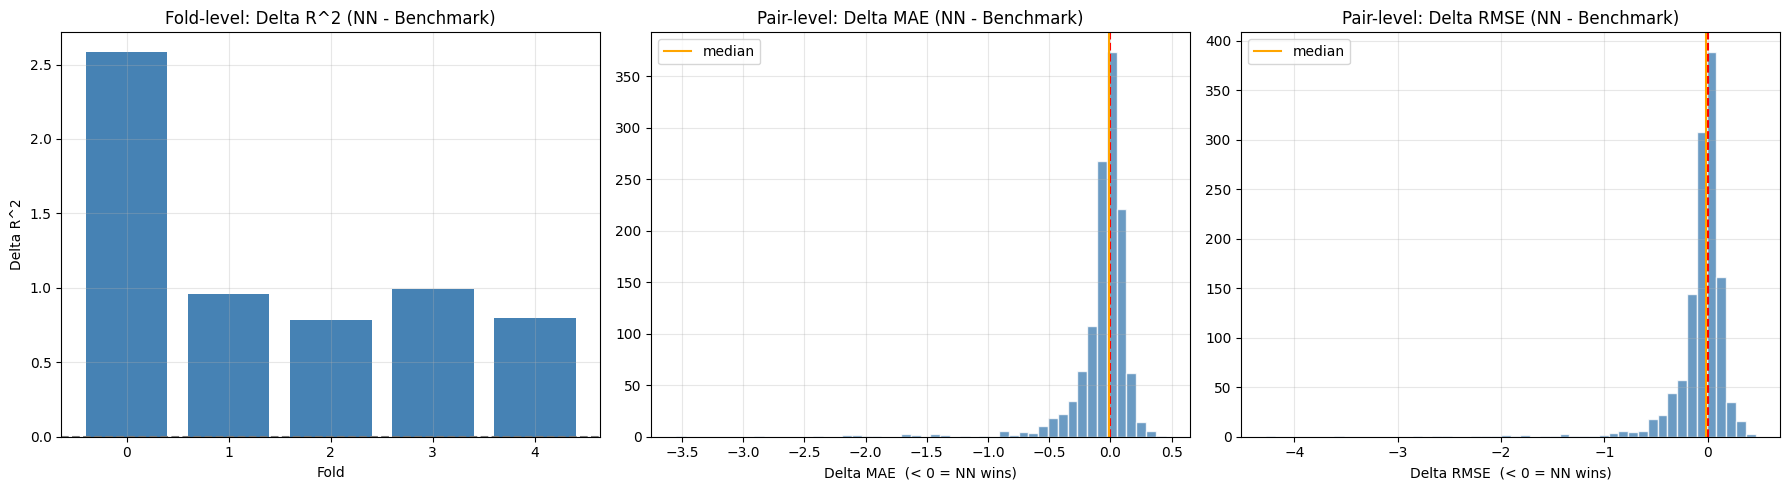

In [6]:
# ============================================================
# BLOCK 1 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a) Delta R² by fold
axes[0].bar(gen_fold["fold"].astype(str), gen_fold["delta_r2"], color="steelblue")
axes[0].axhline(0, ls="--", color="gray")
axes[0].set_title("Fold-level: Delta R^2 (NN - Benchmark)")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Delta R^2")
axes[0].grid(True, alpha=0.3)

# 1b) Histogram of pair-level delta MAE
axes[1].hist(gen_pair["delta_mae"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, ls="--", color="red", lw=1.5)
axes[1].axvline(gen_pair["delta_mae"].median(), ls="-", color="orange", lw=1.5, label="median")
axes[1].set_title("Pair-level: Delta MAE (NN - Benchmark)")
axes[1].set_xlabel("Delta MAE  (< 0 = NN wins)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 1b) Histogram of pair-level delta RMSE
axes[2].hist(gen_pair["delta_rmse"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[2].axvline(0, ls="--", color="red", lw=1.5)
axes[2].axvline(gen_pair["delta_rmse"].median(), ls="-", color="orange", lw=1.5, label="median")
axes[2].set_title("Pair-level: Delta RMSE (NN - Benchmark)")
axes[2].set_xlabel("Delta RMSE  (< 0 = NN wins)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Block 2: Bootstrap elasticity stability setup

In [7]:
# ============================================================
# BLOCK 2 — Better-calculated elasticity (bootstrap stability)
# ============================================================

# The goal of this block is to compare the stability of own-price elasticity estimates
# between the NN and the benchmark using bootstrap confidence intervals.
# The key challenge is that both models operate at different levels of granularity:
# the NN produces one elasticity per (store, upc), while the benchmark produces one per
# directed pair (store, upc_i, upc_j), so the benchmark estimates are first averaged
# across upc_j partners to match the NN's granularity.
# A narrower CI and lower bootstrap std indicate that the model's elasticity estimate
# is more stable across resamples of the data — i.e., less sensitive to which specific
# weeks are included in the training set.
# The same-sign rate and negative rates check economic plausibility: own-price
# elasticities should be negative (downward-sloping demand).

# NN: one own-elasticity per (store, upc)
nn_own_boot = nn_boot_own.copy()
nn_own_boot["ci_width_nn"] = nn_own_boot["elasticity_ci_high"] - nn_own_boot["elasticity_ci_low"]

# Benchmark: one own-elasticity per (store, pair, upc_i, upc_j)
# A given upc_i in a store has multiple estimates (one per upc_j partner).
# Aggregate across partners to get one summary per (store, upc_i).
bench_own_agg = (
    bench_boot_sum
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(
        elast_mean_bench=("own_elasticity_mean", "mean"),
        elast_std_bench=("own_elasticity_std", "mean"),
        ci_low_bench=("own_elasticity_ci_low", "mean"),
        ci_high_bench=("own_elasticity_ci_high", "mean"),
        n_partners=("upc_j", "nunique"),
    )
)
bench_own_agg["ci_width_bench"] = bench_own_agg["ci_high_bench"] - bench_own_agg["ci_low_bench"]

# Merge
elas_cmp = nn_own_boot.merge(
    bench_own_agg,
    left_on=["store_code", "upc_code"],
    right_on=["store_code", "upc_i"],
    how="inner",
)

elas_cmp["nn_narrower_ci"]  = elas_cmp["ci_width_nn"] < elas_cmp["ci_width_bench"]
elas_cmp["nn_lower_std"]    = elas_cmp["elasticity_std"] < elas_cmp["elast_std_bench"]
elas_cmp["same_sign"]       = np.sign(elas_cmp["elasticity_mean"]) == np.sign(elas_cmp["elast_mean_bench"])
elas_cmp["nn_negative"]     = elas_cmp["elasticity_mean"] < 0
elas_cmp["bench_negative"]  = elas_cmp["elast_mean_bench"] < 0

stability = pd.DataFrame({
    "metric": [
        "n_series",
        "nn_narrower_ci_rate",
        "nn_lower_std_rate",
        "same_sign_rate",
        "nn_negative_rate (economic prior)",
        "bench_negative_rate (economic prior)",
        "median_ci_width_nn",
        "median_ci_width_bench",
        "median_std_nn",
        "median_std_bench",
    ],
    "value": [
        len(elas_cmp),
        elas_cmp["nn_narrower_ci"].mean(),
        elas_cmp["nn_lower_std"].mean(),
        elas_cmp["same_sign"].mean(),
        elas_cmp["nn_negative"].mean(),
        elas_cmp["bench_negative"].mean(),
        elas_cmp["ci_width_nn"].median(),
        elas_cmp["ci_width_bench"].median(),
        elas_cmp["elasticity_std"].median(),
        elas_cmp["elast_std_bench"].median(),
    ],
})
display(stability)

,metric,value
0,n_series,212.000000
1,nn_narrower_ci_rate,0.966981
2,nn_lower_std_rate,0.985849
3,same_sign_rate,0.990566
4,nn_negative_rate (economic prior),1.000000
5,bench_negative_rate (economic prior),0.990566
6,median_ci_width_nn,1.090630
7,median_ci_width_bench,2.682516
8,median_std_nn,0.300027
9,median_std_bench,0.789296


# Block 2: Inter-fold elasticity stability

In [8]:
# ============================================================
# BLOCK 2b — Inter-fold elasticity stability
# ============================================================

# The goal of this block is to measure how stable each model's own-price elasticity
# estimate is across different temporal splits, independently of bootstrap resampling.
# For each (store, upc) series, the elasticity is estimated on every k-fold split and
# the standard deviation across those fold-level estimates is used as a proxy for
# temporal stability: a low std means the model consistently recovers a similar
# elasticity regardless of which time window is used for training.
# A minimum of 3 folds is required to compute a meaningful standard deviation.
# This complements the bootstrap stability analysis by capturing a different source
# of variability — temporal distribution shift rather than data resampling noise.

# NN: mean elasticity per (store, upc_i, fold) from k-fold predictions
nn_fold_E = (
    nn_own
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(E_mean=("E", "mean"))
)
nn_fold_std = (
    nn_fold_E
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(E_fold_std_nn=("E_mean", "std"), n_folds_nn=("E_mean", "count"))
)

# Benchmark: own_elasticity per (store, upc_i, fold), averaged over upc_j
bench_fold_E = (
    bench_gen_folds
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(own_elast_mean=("own_elasticity", "mean"))
)
bench_fold_std = (
    bench_fold_E
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(E_fold_std_bench=("own_elast_mean", "std"), n_folds_bench=("own_elast_mean", "count"))
)

# Require at least 3 folds for a meaningful std
fold_cmp = nn_fold_std.merge(bench_fold_std, on=["store_code", "upc_i"])
fold_cmp = fold_cmp[(fold_cmp["n_folds_nn"] >= 3) & (fold_cmp["n_folds_bench"] >= 3)]

fold_cmp["nn_more_stable"] = fold_cmp["E_fold_std_nn"] < fold_cmp["E_fold_std_bench"]

print(f"Series with ≥3 folds: {len(fold_cmp)}")
print(f"NN more stable across folds: {fold_cmp['nn_more_stable'].mean():.1%}")
print(f"Median fold-std NN:    {fold_cmp['E_fold_std_nn'].median():.4f}")
print(f"Median fold-std Bench: {fold_cmp['E_fold_std_bench'].median():.4f}")

Series with ≥3 folds: 272
NN more stable across folds: 74.6%
Median fold-std NN:    0.3928
Median fold-std Bench: 0.6026


# Bock 2c: Bootstrap stability of cross-elasticities

In [9]:
# ============================================================
# BLOCK 4a — Cross-elasticity bootstrap stability (NN vs Benchmark)
# ============================================================
# Same logic as Block 2 but for cross-price elasticities.
# Both models produce one estimate per (store, upc_i, upc_j).
# The benchmark uses symmetrized estimates (average of both directions).

nn_cross = nn_boot_cross.copy()
nn_cross["ci_width_nn"] = nn_cross["elasticity_ci_high"] - nn_cross["elasticity_ci_low"]
nn_cross = nn_cross.rename(columns={
    "elasticity_mean": "elast_mean_nn",
    "elasticity_std":  "elast_std_nn",
})

bench_cross = bench_cross_boot.copy()
bench_cross["ci_width_bench"] = (
    bench_cross["cross_elasticity_sym_ci_high"] - bench_cross["cross_elasticity_sym_ci_low"]
)
bench_cross = bench_cross.rename(columns={
    "upc_a": "upc_i",           
    "upc_b": "upc_j",          
    "cross_elasticity_sym_mean": "elast_mean_bench",
    "cross_elasticity_sym_std":  "elast_std_bench",
})

cross_cmp = nn_cross.merge(
    bench_cross,
    on=["store_code", "upc_i", "upc_j"],
    how="inner",
)

cross_cmp["nn_narrower_ci"] = cross_cmp["ci_width_nn"] < cross_cmp["ci_width_bench"]
cross_cmp["nn_lower_std"]   = cross_cmp["elast_std_nn"] < cross_cmp["elast_std_bench"]
cross_cmp["same_sign"]      = np.sign(cross_cmp["elast_mean_nn"]) == np.sign(cross_cmp["elast_mean_bench"])
cross_cmp["nn_positive"]    = cross_cmp["elast_mean_nn"] > 0
cross_cmp["bench_positive"] = cross_cmp["elast_mean_bench"] > 0

cross_stability = pd.DataFrame({
    "metric": [
        "n_cross_pairs",
        "nn_narrower_ci_rate",
        "nn_lower_std_rate",
        "same_sign_rate",
        "nn_positive_rate (substitutes prior)",
        "bench_positive_rate (substitutes prior)",
        "median_ci_width_nn",
        "median_ci_width_bench",
        "median_std_nn",
        "median_std_bench",
        "median_cross_elast_nn",
        "median_cross_elast_bench",
    ],
    "value": [
        len(cross_cmp),
        cross_cmp["nn_narrower_ci"].mean(),
        cross_cmp["nn_lower_std"].mean(),
        cross_cmp["same_sign"].mean(),
        cross_cmp["nn_positive"].mean(),
        cross_cmp["bench_positive"].mean(),
        cross_cmp["ci_width_nn"].median(),
        cross_cmp["ci_width_bench"].median(),
        cross_cmp["elast_std_nn"].median(),
        cross_cmp["elast_std_bench"].median(),
        cross_cmp["elast_mean_nn"].median(),
        cross_cmp["elast_mean_bench"].median(),
    ],
})

print("=== Cross-elasticity bootstrap stability ===")
display(cross_stability)

=== Cross-elasticity bootstrap stability ===


,metric,value
0,n_cross_pairs,544.000000
1,nn_narrower_ci_rate,0.994485
2,nn_lower_std_rate,0.998162
3,same_sign_rate,0.483456
4,nn_positive_rate (substitutes prior),0.549632
5,bench_positive_rate (substitutes prior),0.338235
6,median_ci_width_nn,0.422638
7,median_ci_width_bench,1.823584
8,median_std_nn,0.099671
9,median_std_bench,0.539109


# Block 2d: Stability inter-fold of cross-elasticities

In [10]:
# ============================================================
# BLOCK 2d — Cross-elasticity inter-fold stability
# ============================================================
# Measures how stable each model's cross-price elasticity estimate
# is across different temporal splits (k-fold).

# NN: mean cross-elasticity per (store, upc_i, upc_j, fold)
nn_cross_kfold = nn_kfold_elas[nn_kfold_elas["type"] == "cross"].copy()

nn_cross_fold_E = (
    nn_cross_kfold
    .groupby(["store_code", "upc_i", "upc_j", "fold"], as_index=False)
    .agg(E_mean=("E", "mean"))
)
nn_cross_fold_std = (
    nn_cross_fold_E
    .groupby(["store_code", "upc_i", "upc_j"], as_index=False)
    .agg(E_fold_std_nn=("E_mean", "std"), n_folds_nn=("E_mean", "count"))
)

# Benchmark: ya tiene una fila por (store, upc_a, upc_b, fold)
bench_cross_fold_std = (
    bench_cross_folds
    .groupby(["store_code", "upc_a", "upc_b"], as_index=False)
    .agg(
        E_fold_std_bench=("cross_elasticity_sym", "std"),
        n_folds_bench=("cross_elasticity_sym", "count"),
    )
    .rename(columns={"upc_a": "upc_i", "upc_b": "upc_j"})
)


cross_fold_cmp = nn_cross_fold_std.merge(
    bench_cross_fold_std,
    on=["store_code", "upc_i", "upc_j"],
)
cross_fold_cmp = cross_fold_cmp[
    (cross_fold_cmp["n_folds_nn"] >= 3) & (cross_fold_cmp["n_folds_bench"] >= 3)
]

cross_fold_cmp["nn_more_stable"] = (
    cross_fold_cmp["E_fold_std_nn"] < cross_fold_cmp["E_fold_std_bench"]
)

print(f"Cross-pairs with ≥3 folds: {len(cross_fold_cmp)}")
print(f"NN more stable across folds: {cross_fold_cmp['nn_more_stable'].mean():.1%}")
print(f"Median fold-std NN:    {cross_fold_cmp['E_fold_std_nn'].median():.4f}")
print(f"Median fold-std Bench: {cross_fold_cmp['E_fold_std_bench'].median():.4f}")

Cross-pairs with ≥3 folds: 948
NN more stable across folds: 90.4%
Median fold-std NN:    0.0533
Median fold-std Bench: 0.2968


# Block 2: Visualization

/tmp/ipykernel_46721/4238128035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


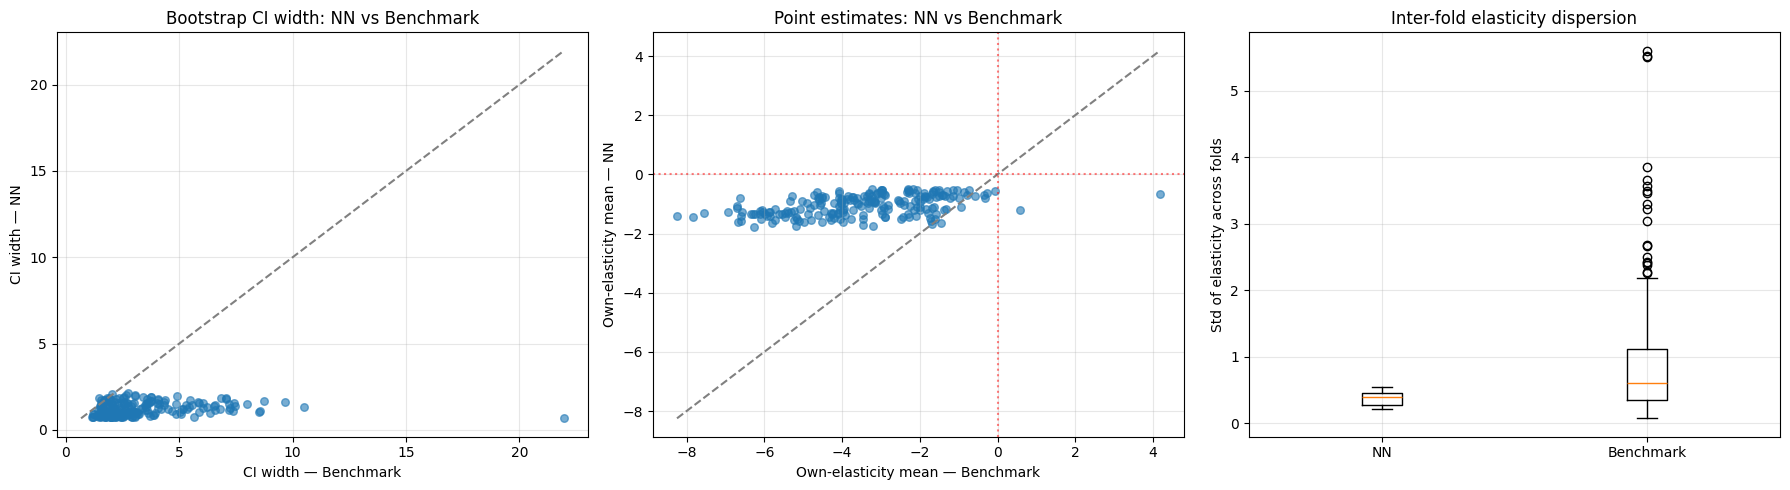

In [11]:
# ============================================================
# BLOCK 2 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CI width scatter
ax = axes[0]
lo = min(elas_cmp["ci_width_bench"].min(), elas_cmp["ci_width_nn"].min())
hi = max(elas_cmp["ci_width_bench"].max(), elas_cmp["ci_width_nn"].max())
ax.scatter(elas_cmp["ci_width_bench"], elas_cmp["ci_width_nn"], alpha=0.6, s=30)
ax.plot([lo, hi], [lo, hi], ls="--", color="gray")
ax.set_xlabel("CI width — Benchmark")
ax.set_ylabel("CI width — NN")
ax.set_title("Bootstrap CI width: NN vs Benchmark")
ax.grid(True, alpha=0.3)

# Elasticity mean scatter
ax = axes[1]
lo = min(elas_cmp["elast_mean_bench"].min(), elas_cmp["elasticity_mean"].min())
hi = max(elas_cmp["elast_mean_bench"].max(), elas_cmp["elasticity_mean"].max())
ax.scatter(elas_cmp["elast_mean_bench"], elas_cmp["elasticity_mean"], alpha=0.6, s=30)
ax.plot([lo, hi], [lo, hi], ls="--", color="gray")
ax.axhline(0, ls=":", color="red", alpha=0.5)
ax.axvline(0, ls=":", color="red", alpha=0.5)
ax.set_xlabel("Own-elasticity mean — Benchmark")
ax.set_ylabel("Own-elasticity mean — NN")
ax.set_title("Point estimates: NN vs Benchmark")
ax.grid(True, alpha=0.3)

# Inter-fold std comparison
ax = axes[2]
ax.boxplot(
    [fold_cmp["E_fold_std_nn"].dropna(), fold_cmp["E_fold_std_bench"].dropna()],
    labels=["NN", "Benchmark"],
)
ax.set_ylabel("Std of elasticity across folds")
ax.set_title("Inter-fold elasticity dispersion")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Block 2: Visualization of cross-elasticities

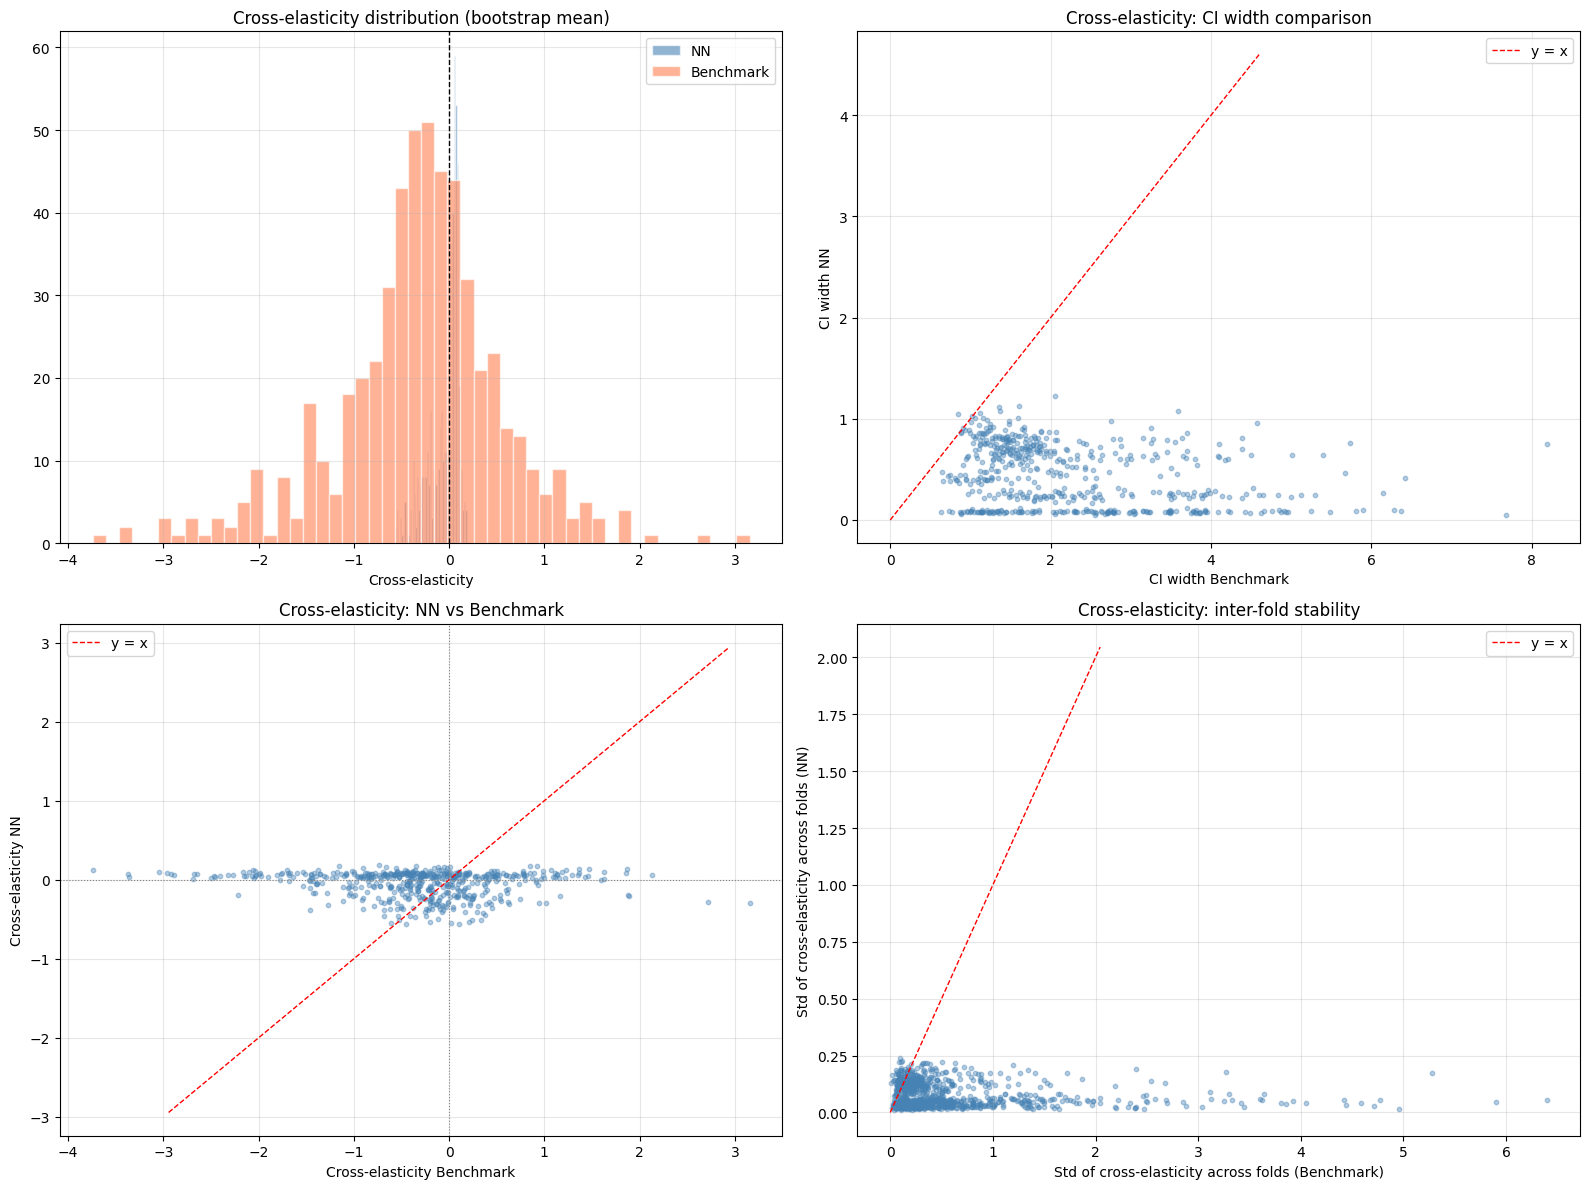

In [12]:
# ============================================================
# BLOCK 4 — Cross-elasticity Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 4a) Distribution of cross-elasticity means: NN vs Benchmark
ax = axes[0, 0]
ax.hist(cross_cmp["elast_mean_nn"], bins=50, alpha=0.6, label="NN", color="steelblue", edgecolor="white")
ax.hist(cross_cmp["elast_mean_bench"], bins=50, alpha=0.6, label="Benchmark", color="coral", edgecolor="white")
ax.axvline(0, ls="--", color="black", lw=1)
ax.set_title("Cross-elasticity distribution (bootstrap mean)")
ax.set_xlabel("Cross-elasticity")
ax.legend()
ax.grid(True, alpha=0.3)

# 4b) CI width comparison
ax = axes[0, 1]
max_w = max(cross_cmp["ci_width_nn"].quantile(0.95), cross_cmp["ci_width_bench"].quantile(0.95))
ax.scatter(cross_cmp["ci_width_bench"], cross_cmp["ci_width_nn"], alpha=0.4, s=10, color="steelblue")
ax.plot([0, max_w], [0, max_w], ls="--", color="red", lw=1, label="y = x")
ax.set_xlabel("CI width Benchmark")
ax.set_ylabel("CI width NN")
ax.set_title("Cross-elasticity: CI width comparison")
ax.legend()
ax.grid(True, alpha=0.3)

# 4c) Cross-elasticity NN vs Benchmark scatter
ax = axes[1, 0]
ax.scatter(cross_cmp["elast_mean_bench"], cross_cmp["elast_mean_nn"], alpha=0.4, s=10, color="steelblue")
lim = max(abs(cross_cmp["elast_mean_nn"]).quantile(0.99), abs(cross_cmp["elast_mean_bench"]).quantile(0.99))
ax.plot([-lim, lim], [-lim, lim], ls="--", color="red", lw=1, label="y = x")
ax.axhline(0, ls=":", color="gray", lw=0.8)
ax.axvline(0, ls=":", color="gray", lw=0.8)
ax.set_xlabel("Cross-elasticity Benchmark")
ax.set_ylabel("Cross-elasticity NN")
ax.set_title("Cross-elasticity: NN vs Benchmark")
ax.legend()
ax.grid(True, alpha=0.3)

# 4d) Inter-fold std comparison
if len(cross_fold_cmp) > 0:
    ax = axes[1, 1]
    max_s = max(
        cross_fold_cmp["E_fold_std_nn"].quantile(0.95),
        cross_fold_cmp["E_fold_std_bench"].quantile(0.95),
    )
    ax.scatter(
        cross_fold_cmp["E_fold_std_bench"],
        cross_fold_cmp["E_fold_std_nn"],
        alpha=0.4, s=10, color="steelblue",
    )
    ax.plot([0, max_s], [0, max_s], ls="--", color="red", lw=1, label="y = x")
    ax.set_xlabel("Std of cross-elasticity across folds (Benchmark)")
    ax.set_ylabel("Std of cross-elasticity across folds (NN)")
    ax.set_title("Cross-elasticity: inter-fold stability")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Block 3: Calibration - Coverage analysis

In [13]:
# ============================================================
# BLOCK 3 — Precise elasticity (calibration analysis)
# ============================================================

# The goal of this block is to assess whether the bootstrap confidence intervals are
# well-calibrated, meaning that a nominal 95% CI should empirically cover approximately
# 95% of independent point estimates.
# The calibration probe works as follows: bootstrap CIs are built from resampled training
# sets, while k-fold point estimates come from entirely different temporal splits.
# If the CI truly reflects the uncertainty in the elasticity estimate, it should contain
# the k-fold estimates at the stated nominal rate.
# A coverage well below 95% signals overconfidence — the CI is too narrow relative to
# how much the estimate actually varies across time windows.
# A coverage well above 95% signals conservatism — the CI is wider than necessary.
# The model closer to 95% has better-calibrated uncertainty, and if it also has a
# narrower CI, its precision claim is genuinely supported by the data.

# --- NN coverage ---
nn_kfold_point = (
    nn_own
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(E_fold=("E", "mean"))
)
nn_ci = nn_boot_own[["store_code", "upc_code", "elasticity_ci_low", "elasticity_ci_high"]]

nn_calib = nn_kfold_point.merge(
    nn_ci,
    left_on=["store_code", "upc_i"],
    right_on=["store_code", "upc_code"],
)
nn_calib["covered"] = (
    (nn_calib["E_fold"] >= nn_calib["elasticity_ci_low"])
    & (nn_calib["E_fold"] <= nn_calib["elasticity_ci_high"])
)

# --- Benchmark coverage ---
bench_kfold_point = (
    bench_gen_folds
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(own_elast_fold=("own_elasticity", "mean"))
)
bench_ci = (
    bench_boot_sum
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(
        ci_low_bench=("own_elasticity_ci_low", "mean"),
        ci_high_bench=("own_elasticity_ci_high", "mean"),
    )
)
bench_calib = bench_kfold_point.merge(bench_ci, on=["store_code", "upc_i"])
bench_calib["covered"] = (
    (bench_calib["own_elast_fold"] >= bench_calib["ci_low_bench"])
    & (bench_calib["own_elast_fold"] <= bench_calib["ci_high_bench"])
)

nn_cov   = nn_calib["covered"].mean()
bench_cov = bench_calib["covered"].mean()

print(f"NN 95% CI coverage over k-fold estimates:        {nn_cov:.1%}  (n={len(nn_calib)})")
print(f"Benchmark 95% CI coverage over k-fold estimates: {bench_cov:.1%}  (n={len(bench_calib)})")
print(f"Target coverage: 95%")
print(f"NN deviation from target:    {abs(nn_cov - 0.95):.1%}  ({'under' if nn_cov < 0.95 else 'over'}confident)")
print(f"Bench deviation from target: {abs(bench_cov - 0.95):.1%}  ({'under' if bench_cov < 0.95 else 'over'}confident)")

NN 95% CI coverage over k-fold estimates:        78.2%  (n=1081)
Benchmark 95% CI coverage over k-fold estimates: 87.4%  (n=1049)
Target coverage: 95%
NN deviation from target:    16.8%  (underconfident)
Bench deviation from target: 7.6%  (underconfident)


## For cross

In [14]:
# ============================================================
# BLOCK 5 — Cross-elasticity calibration (coverage + dispersion)
# ============================================================

# --- NN: k-fold point estimates ---
nn_cross_kfold_point = (
    nn_cross_kfold                                   # tipo == "cross"
    .groupby(["store_code", "upc_i", "upc_j", "fold"], as_index=False)
    .agg(E_fold=("E", "mean"))
)
nn_cross_ci = nn_boot_cross[["store_code", "upc_i", "upc_j",
                              "elasticity_ci_low", "elasticity_ci_high"]].copy()
nn_cross_ci["upc_i"] = nn_cross_ci["upc_i"].astype(str)
nn_cross_ci["upc_j"] = nn_cross_ci["upc_j"].astype(str)
nn_cross_kfold_point["upc_i"] = nn_cross_kfold_point["upc_i"].astype(str)
nn_cross_kfold_point["upc_j"] = nn_cross_kfold_point["upc_j"].astype(str)

nn_cross_calib = nn_cross_kfold_point.merge(
    nn_cross_ci, on=["store_code", "upc_i", "upc_j"]
)
nn_cross_calib["covered"] = (
    (nn_cross_calib["E_fold"] >= nn_cross_calib["elasticity_ci_low"])
    & (nn_cross_calib["E_fold"] <= nn_cross_calib["elasticity_ci_high"])
)

# --- Benchmark: k-fold vs bootstrap CI ---
bench_cross_kfold_point = (
    bench_cross_folds
    .groupby(["store_code", "upc_a", "upc_b", "fold"], as_index=False)
    .agg(E_fold=("cross_elasticity_sym", "mean"))
    .rename(columns={"upc_a": "upc_i", "upc_b": "upc_j"})
)
bench_cross_ci = bench_cross_boot.rename(columns={
    "upc_a": "upc_i", "upc_b": "upc_j",
    "cross_elasticity_sym_ci_low":  "ci_low_bench",
    "cross_elasticity_sym_ci_high": "ci_high_bench",
})[["store_code", "upc_i", "upc_j", "ci_low_bench", "ci_high_bench"]]

bench_cross_calib = bench_cross_kfold_point.merge(
    bench_cross_ci, on=["store_code", "upc_i", "upc_j"]
)
bench_cross_calib["covered"] = (
    (bench_cross_calib["E_fold"] >= bench_cross_calib["ci_low_bench"])
    & (bench_cross_calib["E_fold"] <= bench_cross_calib["ci_high_bench"])
)

# --- Coverage summary ---
nn_cov_cross   = nn_cross_calib["covered"].mean()
bench_cov_cross = bench_cross_calib["covered"].mean()

print(f"NN 95% CI cross coverage:        {nn_cov_cross:.1%}  (n={len(nn_cross_calib)})")
print(f"Benchmark 95% CI cross coverage: {bench_cov_cross:.1%}  (n={len(bench_cross_calib)})")
print(f"Target: 95%")

# --- Dispersion ratio (bootstrap_std / kfold_std) ---
nn_cross_disp = nn_cross_fold_std.merge(
    nn_boot_cross[["store_code", "upc_i", "upc_j", "elasticity_std"]].rename(
        columns={"elasticity_std": "boot_std_nn"}
    ),
    on=["store_code", "upc_i", "upc_j"],
)
nn_cross_disp["ratio_nn"] = nn_cross_disp["boot_std_nn"] / nn_cross_disp["E_fold_std_nn"].replace(0, np.nan)

bench_cross_disp = bench_cross_fold_std.merge(
    bench_cross_boot.rename(columns={
        "upc_a": "upc_i", "upc_b": "upc_j",
        "cross_elasticity_sym_std": "boot_std_bench",
    })[["store_code", "upc_i", "upc_j", "boot_std_bench"]],
    on=["store_code", "upc_i", "upc_j"],
)
bench_cross_disp["ratio_bench"] = bench_cross_disp["boot_std_bench"] / bench_cross_disp["E_fold_std_bench"].replace(0, np.nan)

print(f"\nDispersion ratio = bootstrap_std / kfold_std  (ideal ≈ 1.0)")
print(f"  NN median ratio:        {nn_cross_disp['ratio_nn'].median():.2f}")
print(f"  Benchmark median ratio: {bench_cross_disp['ratio_bench'].median():.2f}")

NN 95% CI cross coverage:        92.9%  (n=2714)
Benchmark 95% CI cross coverage: 90.8%  (n=2698)
Target: 95%

Dispersion ratio = bootstrap_std / kfold_std  (ideal ≈ 1.0)
  NN median ratio:        1.26
  Benchmark median ratio: 1.79


# Block 3: Dispersion ratio

In [15]:
# ============================================================
# BLOCK 3b — Dispersion ratio: bootstrap std vs k-fold std
# ============================================================

# The goal of this block is to cross-validate the bootstrap uncertainty estimates
# against the temporal variability observed in k-fold, using a dispersion ratio
# defined as bootstrap_std / kfold_std for each (store, upc) series.
# A ratio close to 1.0 means the bootstrap is correctly sizing the uncertainty:
# it captures roughly the same spread as actually observed across time windows.
# A ratio below 1.0 means the bootstrap underestimates true variability —
# the estimate is more sensitive to the time period than the bootstrap suggests.
# A ratio above 1.0 means the bootstrap is conservative —
# it inflates uncertainty beyond what temporal variation alone would justify.
# Series with zero fold-std are excluded to avoid division by zero and because
# a perfectly stable k-fold estimate provides no meaningful calibration signal.

disp = nn_fold_std.merge(
    nn_boot_own[["store_code", "upc_code", "elasticity_std"]],
    left_on=["store_code", "upc_i"],
    right_on=["store_code", "upc_code"],
)
disp = disp[disp["E_fold_std_nn"] > 0]
disp["ratio_nn"] = disp["elasticity_std"] / disp["E_fold_std_nn"]

bench_boot_std_agg = (
    bench_boot_sum
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(elast_std_bench=("own_elasticity_std", "mean"))
)
disp_bench = bench_fold_std.merge(bench_boot_std_agg, on=["store_code", "upc_i"])
disp_bench = disp_bench[disp_bench["E_fold_std_bench"] > 0]
disp_bench["ratio_bench"] = disp_bench["elast_std_bench"] / disp_bench["E_fold_std_bench"]

print("Dispersion ratio = bootstrap_std / kfold_std  (ideal ≈ 1.0)")
print(f"  NN median ratio:        {disp['ratio_nn'].median():.2f}")
print(f"  Benchmark median ratio: {disp_bench['ratio_bench'].median():.2f}")

Dispersion ratio = bootstrap_std / kfold_std  (ideal ≈ 1.0)
  NN median ratio:        0.97
  Benchmark median ratio: 1.35


# Block 3: Visualization

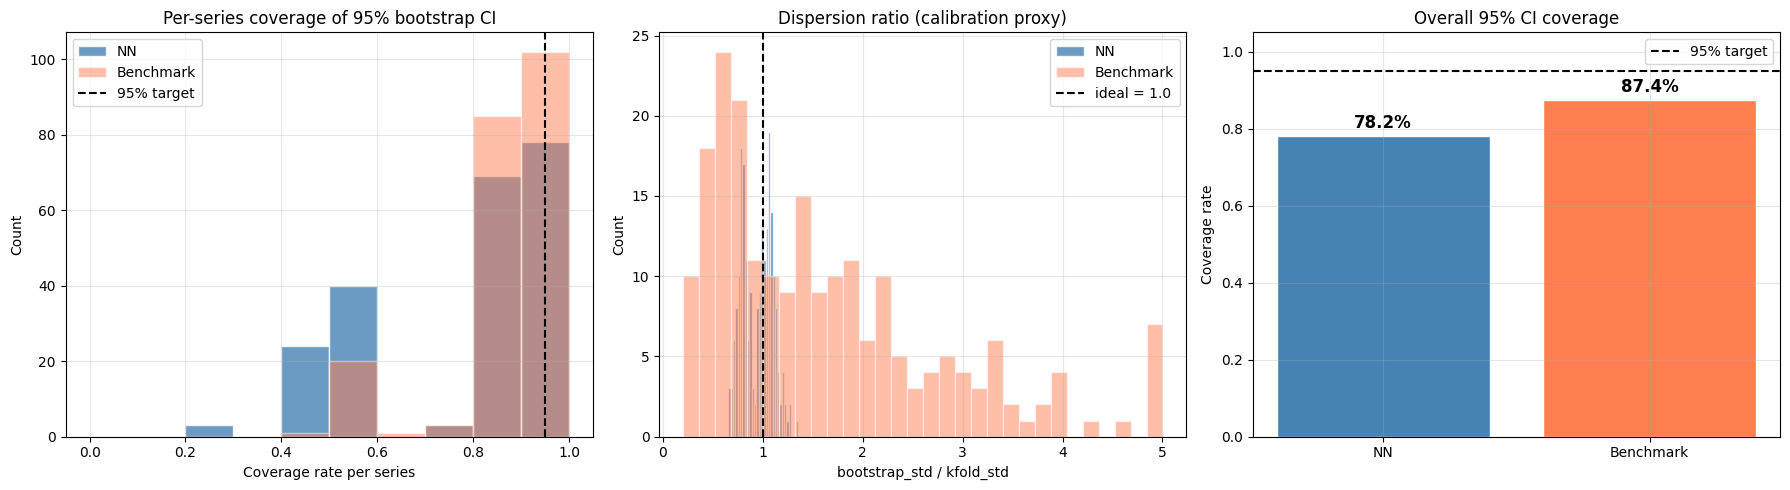

In [16]:
# ============================================================
# BLOCK 3 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coverage per series (NN)
nn_series_cov = (
    nn_calib
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(coverage=("covered", "mean"), n_folds=("covered", "count"))
)
ax = axes[0]
ax.hist(nn_series_cov["coverage"], bins=np.linspace(0, 1, 11),
        color="steelblue", edgecolor="white", alpha=0.8, label="NN")
bench_series_cov = (
    bench_calib
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(coverage=("covered", "mean"))
)
ax.hist(bench_series_cov["coverage"], bins=np.linspace(0, 1, 11),
        color="coral", edgecolor="white", alpha=0.5, label="Benchmark")
ax.axvline(0.95, ls="--", color="black", label="95% target")
ax.set_xlabel("Coverage rate per series")
ax.set_ylabel("Count")
ax.set_title("Per-series coverage of 95% bootstrap CI")
ax.legend()
ax.grid(True, alpha=0.3)

# Dispersion ratio histograms
ax = axes[1]
ax.hist(disp["ratio_nn"].clip(0, 5), bins=30,
        color="steelblue", edgecolor="white", alpha=0.8, label="NN")
ax.hist(disp_bench["ratio_bench"].clip(0, 5), bins=30,
        color="coral", edgecolor="white", alpha=0.5, label="Benchmark")
ax.axvline(1.0, ls="--", color="black", label="ideal = 1.0")
ax.set_xlabel("bootstrap_std / kfold_std")
ax.set_ylabel("Count")
ax.set_title("Dispersion ratio (calibration proxy)")
ax.legend()
ax.grid(True, alpha=0.3)

# Calibration summary bar chart
ax = axes[2]
labels = ["NN", "Benchmark"]
coverages = [nn_cov, bench_cov]
colors = ["steelblue", "coral"]
bars = ax.bar(labels, coverages, color=colors, edgecolor="white")
ax.axhline(0.95, ls="--", color="black", label="95% target")
ax.set_ylabel("Coverage rate")
ax.set_title("Overall 95% CI coverage")
ax.set_ylim(0, 1.05)
for bar, v in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()